In [1]:
from autocvd import autocvd
autocvd(num_gpus = 1, interval=1)
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '5'

import numpy as np
import matplotlib.pyplot as plt
import time 
from functools import partial  # Change this line - lowercase 'partial'

import jax.numpy as jnp
import jax
from jax import jit
from jax.scipy.special import logsumexp


# jax.config.update("jax_enable_x64", True)
from jax.sharding import Mesh, PartitionSpec, NamedSharding         #IMPORT NEEDED FOR AUTOMATIC PARALLELISM
from jax.experimental import shard_map



import pandas as pd
import seaborn as sns
from chainconsumer import Chain, ChainConsumer, Truth



from odisseo import construct_initial_state
from odisseo.dynamics import  DIRECT_ACC_MATRIX, DIRECT_ACC_LAXMAP
from odisseo.option_classes import SimulationConfig, SimulationParams, MNParams, NFWParams, PlummerParams, PSPParams, MN_POTENTIAL, NFW_POTENTIAL, PSP_POTENTIAL, TSIT5, DIFFRAX_BACKEND
from odisseo.initial_condition import Plummer_sphere
from odisseo.time_integration import time_integration
from odisseo.units import CodeUnits
from odisseo.utils import projection_on_GD1
from astropy import units as u
import blackjax
from tqdm import tqdm


code_length = 10.0 * u.kpc
code_mass = 1e4 * u.Msun
code_time = 3 * u.Gyr
code_units = CodeUnits(code_length, code_mass, G=1, unit_time = code_time )  
N_particles = 1_000

pos_com_final = jnp.array([[11.8, 0.79, 6.4]]) * u.kpc.to(code_units.code_length)
vel_com_final = jnp.array([[109.5,-254.5,-90.3]]) * (u.km/u.s).to(code_units.code_velocity)

config_sim = SimulationConfig(N_particles = N_particles,
                            return_snapshots = False, 
                            num_timesteps = 1000, 
                            external_accelerations=(NFW_POTENTIAL, MN_POTENTIAL, PSP_POTENTIAL), 
                            acceleration_scheme = DIRECT_ACC_MATRIX,
                            softening = (0.1 * u.pc).to(code_units.code_length).value,
                             integrator = DIFFRAX_BACKEND,
                             fixed_timestep = False,
                             diffrax_solver = TSIT5,
                            ) #default values
        #the center of mass needs to be integrated backwards in time first 
config_com = config_sim._replace(N_particles=1,)

@jit
def run_simulation(rng_key, params):
    params_samples = SimulationParams(t_end = params['t_end'] * u.Gyr.to(code_units.code_time),
                        Plummer_params = PlummerParams(Mtot=params['Mtot'] * u.Msun.to(code_units.code_mass),
                                                       a = params['a_Plummer'] * u.kpc.to(code_units.code_length),),
                        NFW_params = NFWParams(Mvir=params['M_NFW'] * u.Msun.to(code_units.code_mass),
                                               r_s= params['r_s'] * u.kpc.to(code_units.code_length)),
                        MN_params = MNParams(M = params['M_MN'] * u.Msun.to(code_units.code_mass),
                                             a = params['a_MN'] * u.kpc.to(code_units.code_length),
                                            b = (0.280 * u.kpc).to(code_units.code_length).value),
                        PSP_params= PSPParams(M = 4501365375.06545 * u.Msun.to(code_units.code_mass),
                                                alpha = 1.8, 
                                                r_c = (1.9*u.kpc).to(code_units.code_length).value),  
                        G = code_units.G, )

    params_com = params_samples._replace(t_end=-params_samples.t_end,)
    mass_com = jnp.array([params_samples.Plummer_params.Mtot]) 
    
    #we construmt the initial state of the com 
    initial_state_com = construct_initial_state(pos_com_final, vel_com_final,)
    #we run the simulation backwards in time for the center of mass
    final_state_com = time_integration(initial_state_com, mass_com, config=config_com, params=params_com)
    #we calculate the final position and velocity of the center of mass
    pos_com = final_state_com[:, 0]
    vel_com = final_state_com[:, 1]

    #we construct the initial state of the Plummer sphere
    positions, velocities, mass = Plummer_sphere(key=rng_key, params=params_samples, config=config_sim)
    #we add the center of mass position and velocity to the Plummer sphere particles
    positions = positions + pos_com
    velocities = velocities + vel_com
    #initialize the initial state
    initial_state_stream = construct_initial_state(positions, velocities, )
    #run the simulation
    final_state = time_integration(initial_state_stream, mass, config=config_sim, params=params_samples)

    #projection on the GD1 stream
    stream = projection_on_GD1(final_state, code_units=code_units,)

    return stream


# Utility: ensure non-neg and avoid zeros
@jit
def _safe(d, eps=1e-12):
    return jnp.clip(d, a_min=eps)


@jit
def loss_js(d_target, d_sim):
    p = _safe(d_target) / jnp.sum(_safe(d_target))
    q = _safe(d_sim)   / jnp.sum(_safe(d_sim))
    m = 0.5 * (p + q)
    return 0.5 * (jnp.sum(p * (jnp.log(p) - jnp.log(m))) + jnp.sum(q * (jnp.log(q) - jnp.log(m))))

@jit
def cross_entropy(d_target, d_sim):
    p = _safe(d_target) / jnp.sum(_safe(d_target))
    q = _safe(d_sim)   / jnp.sum(_safe(d_sim))
    # cross-entropy
    return -jnp.sum(p * jnp.log(q))

# Define bin edges and create meshgrids
phi1_bins = jnp.linspace(-120, 70, 65)    # 64 bins
phi2_bins = jnp.linspace(-8, 2, 33)       # 32 bins
v1_bins = jnp.linspace(-2., 1.0, 65)      # 64 bins  
v2_bins = jnp.linspace(-0.10, 0.10, 33)   # 32 bins
R_bins = jnp.linspace(6, 20, 65)          # 64 bins
vR_bins = jnp.linspace(-250, 250, 33)     # 32 bins


# Create meshgrids for bin edges (not centers)
PHI1, PHI2 = jnp.meshgrid(phi1_bins, phi2_bins, indexing='ij')
V1, V2 = jnp.meshgrid(v1_bins, v2_bins, indexing='ij')
R_GRID, VR_GRID = jnp.meshgrid(R_bins, vR_bins, indexing='ij')


@jit
def kde2d_on_grid(x, grid_x, grid_y, bandwidth):
    """
    Evaluate 2D Gaussian KDE on a meshgrid.
    """
    N, d = x.shape
    assert d == 2

    # Flatten grid to (G, 2)
    grid_points = jnp.stack([grid_x.ravel(), grid_y.ravel()], axis=1)  # (G,2)

    # Differences (G, N, 2)
    diff = grid_points[:, None, :] - x[None, :, :]

    # Bandwidth handling
    bw = jnp.atleast_1d(bandwidth)
    if bw.shape == (1,):
        bw = jnp.repeat(bw, 2)
    var = bw**2

    # Mahalanobis distance
    sq = (diff**2) / var  # (G,N,2)

    # log kernel for each (gridpoint, datapoint)
    logk = -0.5 * jnp.sum(sq, axis=-1) - 0.5*jnp.sum(jnp.log(2*jnp.pi*var))

    # logsumexp over datapoints
    log_dens = logsumexp(logk, axis=1) - jnp.log(N)

    return jnp.exp(log_dens).reshape(grid_x.shape)


@jit
def densities(stream):
    # take relevant projections from simulated stream
    xs = jnp.array([
        stream[:, [1, 2]],  # phi
        stream[:, [4, 5]],  # v
        stream[:, [0, 3]],  # R
    ])
    grids = jnp.array([
        [PHI1, PHI2],
        [V1, V2],
        [R_GRID, VR_GRID],
    ])
    bws = jnp.array([
        [2.0, 0.5],   # phi
        [0.1, 0.01],  # v
        [0.5, 20.0],  # R
    ])

    # vmap over the 3 projections
    dens_all = jax.vmap(
        lambda x, grid, bw: kde2d_on_grid(x, grid[0], grid[1], bw)
    )(xs, grids, bws)

    # unpack densities
    dens_phi, dens_v, dens_R = dens_all
    return dens_phi, dens_v, dens_R

@jit
def stream_likelihood(model_stream, ):
    
    dens_phi, dens_v, dens_R = densities(model_stream)


    return jnp.exp(- 10 * (
            loss_js(dens_phi_target, dens_phi) 
            +
            loss_js(dens_v_target, dens_v) 
            + 
            loss_js(dens_R_target, dens_R)
            )
            )


true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
observation = jnp.array(np.load(true_GD1_observation_path)['x']).reshape(1000, 6)
true_theta = jnp.array(np.load(true_GD1_observation_path)['theta'])

# ----------------------------- Load observation & precompute target densities ----------------
true_GD1_observation_path = '/export/data/vgiusepp/odisseo_data/data_fix_position/true.npz'
_obs = np.load(true_GD1_observation_path)
observation = jnp.array(_obs['x']).reshape(1000, 6)  # will be used only to compute target densities
true_theta = jnp.array(_obs['theta'])

# Precompute the target densities ONCE (expensive step)
dens_phi_target, dens_v_target, dens_R_target = densities(observation)


@jit
def evaluate_loglikelihood(theta_1, ):

        key = jax.random.PRNGKey(0)
        # print(f"In the corrector: theta_1 shape: {theta_1.shape}, target shape: {target.shape}")
        output = run_simulation(key, theta_1)

        # return stream_likelihood(model_stream=output, obs_stream=observation, obs_errors=jnp.array([0.25, 0.001, 0.15, 5., 0.1, 0.0001]))
        return jnp.log(stream_likelihood(model_stream=output, ))

# True parameter values (without code_units transformation)
true_params = jnp.array([
    3.0,                    # t_end (Gyr)
    10**4.05,              # Plummer Mtot (Msun) 
    8.0 * 1e-3,            # Plummer a (kpc) - converted from pc to kpc
    4.3683325e11,          # NFW Mvir (Msun)
    16.0,                  # NFW r_s (kpc)
    68_193_902_782.346756, # MN M (Msun)
    3.0,                   # MN a (kpc)
])

# Prior bounds for each parameter
prior_bounds = jnp.array([
    [0.5, 5.0],                    # t_end: 0.5 to 5 Gyr
    [10**3, 10**4.5],              # Plummer Mtot: 10^3 to 10^4.5 Msun
    [8.0 * 1e-3 * 0.25, 8.0 * 1e-3 * 2.0],  # Plummer a: 1/4 to 2x true (kpc)
    [4.3683325e11 * 0.25, 4.3683325e11 * 2.0],  # NFW Mvir: 1/4 to 2x true
    [16.0 * 0.25, 16.0 * 2.0],    # NFW r_s: 1/4 to 2x true (kpc)
    [68_193_902_782.346756 * 0.25, 68_193_902_782.346756 * 2.0],  # MN M: 1/4 to 2x true
    [3.0 * 0.25, 3.0 * 2.0],      # MN a: 1/4 to 2x true (kpc)
])  # Shape: (7, 2) for [min, max] bounds

def draw_from_prior(key):
    """Draw samples from uniform prior."""
    key, subkey = jax.random.split(key)
    u = jax.random.uniform(subkey, shape=(7,))
    
    # Transform uniform [0,1] to [min, max] for each parameter
    samples = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])
    samples = {'t_end': samples[0], 'Mtot': samples[1], 'a_Plummer': samples[2], 'M_NFW': samples[3], 'r_s': samples[4], 'M_MN': samples[5], 'a_MN': samples[6]}
    return samples

param_order = ['t_end', 'Mtot', 'a_Plummer', 'M_NFW', 'r_s', 'M_MN', 'a_MN']
@jit
def dict_to_array(theta_dict):
    return jnp.array([theta_dict[k] for k in param_order])

@jit
def array_to_dict(theta_array):
    return {k: theta_array[i] for i, k in enumerate(param_order)}

@jit
def evaluate_log_prior(theta):
    """Evaluate log prior density (uniform)."""
    # Check if all parameters are within bounds 
    # theta = jnp.array([theta['t_end'], theta['Mtot'], theta['a_Plummer'], theta['M_NFW'], theta['r_s'], theta['M_MN'], theta['a_MN']])
    # in_bounds = jnp.all((theta >= prior_bounds[:, 0]) & (theta <= prior_bounds[:, 1])) 
    in_bounds = jnp.all(jnp.array([
        (theta['t_end'] >= prior_bounds[0, 0]) & (theta['t_end'] <= prior_bounds[0, 1]),
        (theta['Mtot'] >= prior_bounds[1, 0]) & (theta['Mtot'] <= prior_bounds[1, 1]),
        (theta['a_Plummer'] >= prior_bounds[2, 0]) & (theta['a_Plummer'] <= prior_bounds[2, 1]),    
        (theta['M_NFW'] >= prior_bounds[3, 0]) & (theta['M_NFW'] <= prior_bounds[3, 1]),
        (theta['r_s'] >= prior_bounds[4, 0]) & (theta['r_s'] <= prior_bounds[4, 1]),
        (theta['M_MN'] >= prior_bounds[5, 0]) & (theta['M_MN'] <= prior_bounds[5, 1]),
        (theta['a_MN'] >= prior_bounds[6, 0]) & (theta['a_MN'] <= prior_bounds[6, 1]),
    ]))
    
    # For uniform distribution: log(density) = -log(volume)
    # Volume = product of interval widths
    log_volume = jnp.sum(jnp.log(prior_bounds[:, 1] - prior_bounds[:, 0]))
    
    # Return -inf if out of bounds, -log_volume if in bounds
    return jnp.where(in_bounds, -log_volume/10000, -jnp.inf)
    # return -log_volume


def draw_from_proposal(key, theta, sigma2_prop):
    key, sk = jax.random.split(key)
    theta_prime = jax.random.normal(sk, shape=theta.shape) * jnp.sqrt(sigma2_prop) + theta
    return theta_prime, key

@jit
def evaluate_log_posterior_grad(theta):
    """Compute gradient of log posterior."""
    
    def log_posterior(theta):
        log_prior = evaluate_log_prior(theta)
        log_like = evaluate_loglikelihood(theta)
        return log_prior + log_like
    
    # Get both value and gradient
    log_post_val, grad = jax.value_and_grad(log_posterior)(theta)
    return log_post_val, grad

@jit
def evaluate_log_posterior(theta):
    log_prior = evaluate_log_prior(theta)
    log_like = evaluate_loglikelihood(theta_1 = theta, )
    return log_prior + log_like



In [2]:
# # Calculate rough standard deviations from your prior bounds
# prior_stds = (prior_bounds[:, 1] - prior_bounds[:, 0]) / 4  # Rough estimate

# # Use as initial proposal sigmas (different for each parameter)
# inverse_mass_matrix = (prior_stds * 0.1) ** 2  # Start with 10% of range

# # Build the kernel
# step_size = 1e-3
# nuts = blackjax.nuts(evaluate_log_posterior, step_size, inverse_mass_matrix)

# # Initialize the state
# initial_position = draw_from_prior(jax.random.PRNGKey(42))
# state = nuts.init(initial_position)

# # Iterate
# rng_key = jax.random.key(0)
# step = jax.jit(nuts.step)
# for i in tqdm(range(1_000)):
#     nuts_key = jax.random.fold_in(rng_key, i)
#     state, _ = step(nuts_key, state)

In [ ]:


# Fix: Create a proper random step function instead of passing an array
def random_step_fn(rng_key, position):
    """Generate random step proposals for each parameter."""
    # Use different step sizes for different parameters based on their scale
    # step_sizes = jnp.array([
    #     0.1,    # t_end (Gyr) - smaller steps
    #     100.0,  # Mtot (Msun) - larger steps for large values
    #     0.001,  # a_Plummer (kpc) - very small steps
    #     1e10,    # M_NFW (Msun) - large steps for large values  
    #     1.0,    # r_s (kpc)
    #     1e9,    # M_MN (Msun) - large steps for large values
    #     0.2,    # a_MN (kpc)
    # ])
    step_sizes = jnp.array([
        0.5*1,    # t_end (Gyr) - smaller steps
        0.5*3000.0,  # Mtot (Msun) - larger steps for large values
        0.5*0.0001,  # a_Plummer (kpc) - very small steps
        0.5*1e11,    # M_NFW (Msun) - large steps for large values  
        0.5*10.0,    # r_s (kpc)
        0.5*1e11,    # M_MN (Msun) - large steps for large values
        0.5*1,    # a_MN (kpc)
    ])
    
    # Generate random steps
    random_steps = jax.random.normal(rng_key, shape=(7,)) * 0.1 * step_sizes

    # Convert to dictionary format to match your position format
    step_dict = {
        't_end': random_steps[0],
        'Mtot': random_steps[1], 
        'a_Plummer': random_steps[2],
        'M_NFW': random_steps[3],
        'r_s': random_steps[4],
        'M_MN': random_steps[5],
        'a_MN': random_steps[6]
    }
    return step_dict

# Build the kernel
rmh = blackjax.additive_step_random_walk(
    logdensity_fn=evaluate_log_posterior,
    random_step=random_step_fn
)

# Initialize the state
posterior_SBI = np.load('../logs/OdisseoCrossAttentionSetTransformer_small_AllParameters_Position_uniforprior_2e5_TSIT5/pictures/predicted_theta_test_set.npz')['predicted_theta'][0]
init_positions = np.mean(posterior_SBI, axis=0)
init_positions = array_to_dict(init_positions)
init_positions['M_NFW'] = 10**init_positions['M_NFW']
init_positions['M_MN'] = 10**init_positions['M_MN']
init_positions['Mtot'] = 10**init_positions['Mtot']
state = rmh.init(init_positions)


from blackjax.util import run_inference_algorithm

final_state, history_state = run_inference_algorithm(
    rng_key=jax.random.PRNGKey(0),
    inference_algorithm=rmh,
    num_steps=1000,
    initial_state=state,
    progress_bar=True,
)

In [4]:
final_state

RWState(position={'M_MN': Array(6.2462706e+10, dtype=float32), 'M_NFW': Array(6.043968e+11, dtype=float32), 'Mtot': Array(22545.16, dtype=float32), 'a_MN': Array(2.6482022, dtype=float32), 'a_Plummer': Array(0.00909713, dtype=float32), 'r_s': Array(20.612171, dtype=float32), 't_end': Array(3.9239473, dtype=float32)}, logdensity=Array(-0.01667826, dtype=float32))

In [ ]:
history_state

(RWState(position={'M_MN': Array([7.15634688e+10, 7.29962332e+10, 7.80266619e+10, 8.73832776e+10,
        9.07153080e+10, 8.96519619e+10, 8.96234209e+10, 9.82360146e+10,
        9.14223923e+10, 9.45812439e+10, 8.60518973e+10, 8.66558362e+10,
        9.48213187e+10, 1.01160051e+11, 9.49965783e+10, 9.34737674e+10,
        8.42114253e+10, 7.95469169e+10, 7.70099528e+10, 7.27163945e+10,
        7.01779640e+10, 6.84700385e+10, 7.42978109e+10, 6.79791002e+10,
        6.64123597e+10, 7.33157130e+10, 6.68217057e+10, 5.82240829e+10,
        5.41583524e+10, 5.32496220e+10, 5.16708516e+10, 5.55735859e+10,
        6.14327296e+10, 6.37827400e+10, 5.77308262e+10, 5.65414093e+10,
        5.37808527e+10, 5.33725389e+10, 5.24108718e+10, 5.13877729e+10,
        5.65343969e+10, 5.91660483e+10, 5.63453706e+10, 6.63158292e+10,
        6.94487040e+10, 6.95878697e+10, 6.85429187e+10, 6.82937917e+10,
        6.58497577e+10, 6.60183040e+10, 6.90637373e+10, 7.16808192e+10,
        7.63150418e+10, 7.41566874e+10

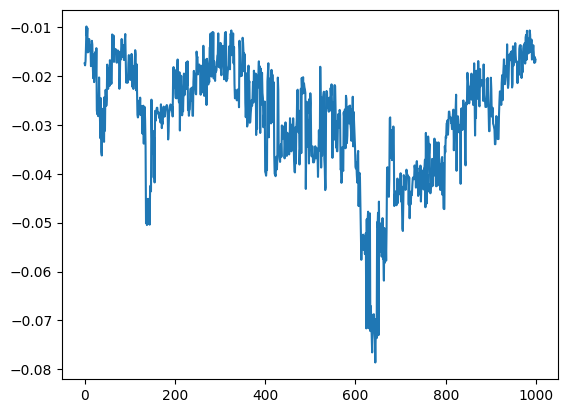

In [6]:
plt.plot(history_state[0].logdensity)

In [7]:
RWState = history_state[0]
positions = RWState.position
df = pd.DataFrame(positions)

In [8]:
df

,M_MN,M_NFW,Mtot,a_MN,a_Plummer,r_s,t_end
0,7.156347e+10,5.385638e+11,17152.906250,3.573884,0.009168,20.308199,2.812041
1,7.299623e+10,5.365109e+11,17037.378906,3.623612,0.009162,19.805370,2.821986
2,7.802666e+10,5.362036e+11,16908.308594,3.581005,0.009158,19.750555,2.747766
3,8.738328e+10,5.404181e+11,17008.193359,3.620265,0.009157,20.491089,2.831857
4,9.071531e+10,5.319281e+11,16816.892578,3.612643,0.009156,20.247398,2.875135
...,...,...,...,...,...,...,...
995,7.693118e+10,5.876626e+11,23007.357422,2.836933,0.009087,21.605988,3.907145
996,7.187238e+10,5.891370e+11,22724.597656,2.707750,0.009089,21.860237,3.843483
997,6.823783e+10,5.921072e+11,22837.031250,2.727832,0.009095,20.731325,3.890481
998,6.269148e+10,5.947630e+11,22847.480469,2.655858,0.009095,20.358629,3.912750


In [9]:
history_state[0].position

{'M_MN': Array([7.15634688e+10, 7.29962332e+10, 7.80266619e+10, 8.73832776e+10,
        9.07153080e+10, 8.96519619e+10, 8.96234209e+10, 9.82360146e+10,
        9.14223923e+10, 9.45812439e+10, 8.60518973e+10, 8.66558362e+10,
        9.48213187e+10, 1.01160051e+11, 9.49965783e+10, 9.34737674e+10,
        8.42114253e+10, 7.95469169e+10, 7.70099528e+10, 7.27163945e+10,
        7.01779640e+10, 6.84700385e+10, 7.42978109e+10, 6.79791002e+10,
        6.64123597e+10, 7.33157130e+10, 6.68217057e+10, 5.82240829e+10,
        5.41583524e+10, 5.32496220e+10, 5.16708516e+10, 5.55735859e+10,
        6.14327296e+10, 6.37827400e+10, 5.77308262e+10, 5.65414093e+10,
        5.37808527e+10, 5.33725389e+10, 5.24108718e+10, 5.13877729e+10,
        5.65343969e+10, 5.91660483e+10, 5.63453706e+10, 6.63158292e+10,
        6.94487040e+10, 6.95878697e+10, 6.85429187e+10, 6.82937917e+10,
        6.58497577e+10, 6.60183040e+10, 6.90637373e+10, 7.16808192e+10,
        7.63150418e+10, 7.41566874e+10, 6.76033290e+10, 

Original samples: 1 chains × 1000 samples = 1000
  Chain 0: 967/1000 accepted (96.7%)
📊 Total accepted samples: 967/1000 (96.7%)
📈 Final samples for plotting: 867
🎨 Creating corner plot...


Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{NFW}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{Plummer}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{MN}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $r_s$ [kpc] in chain MCMC Posterior (Filtered) is not constrained


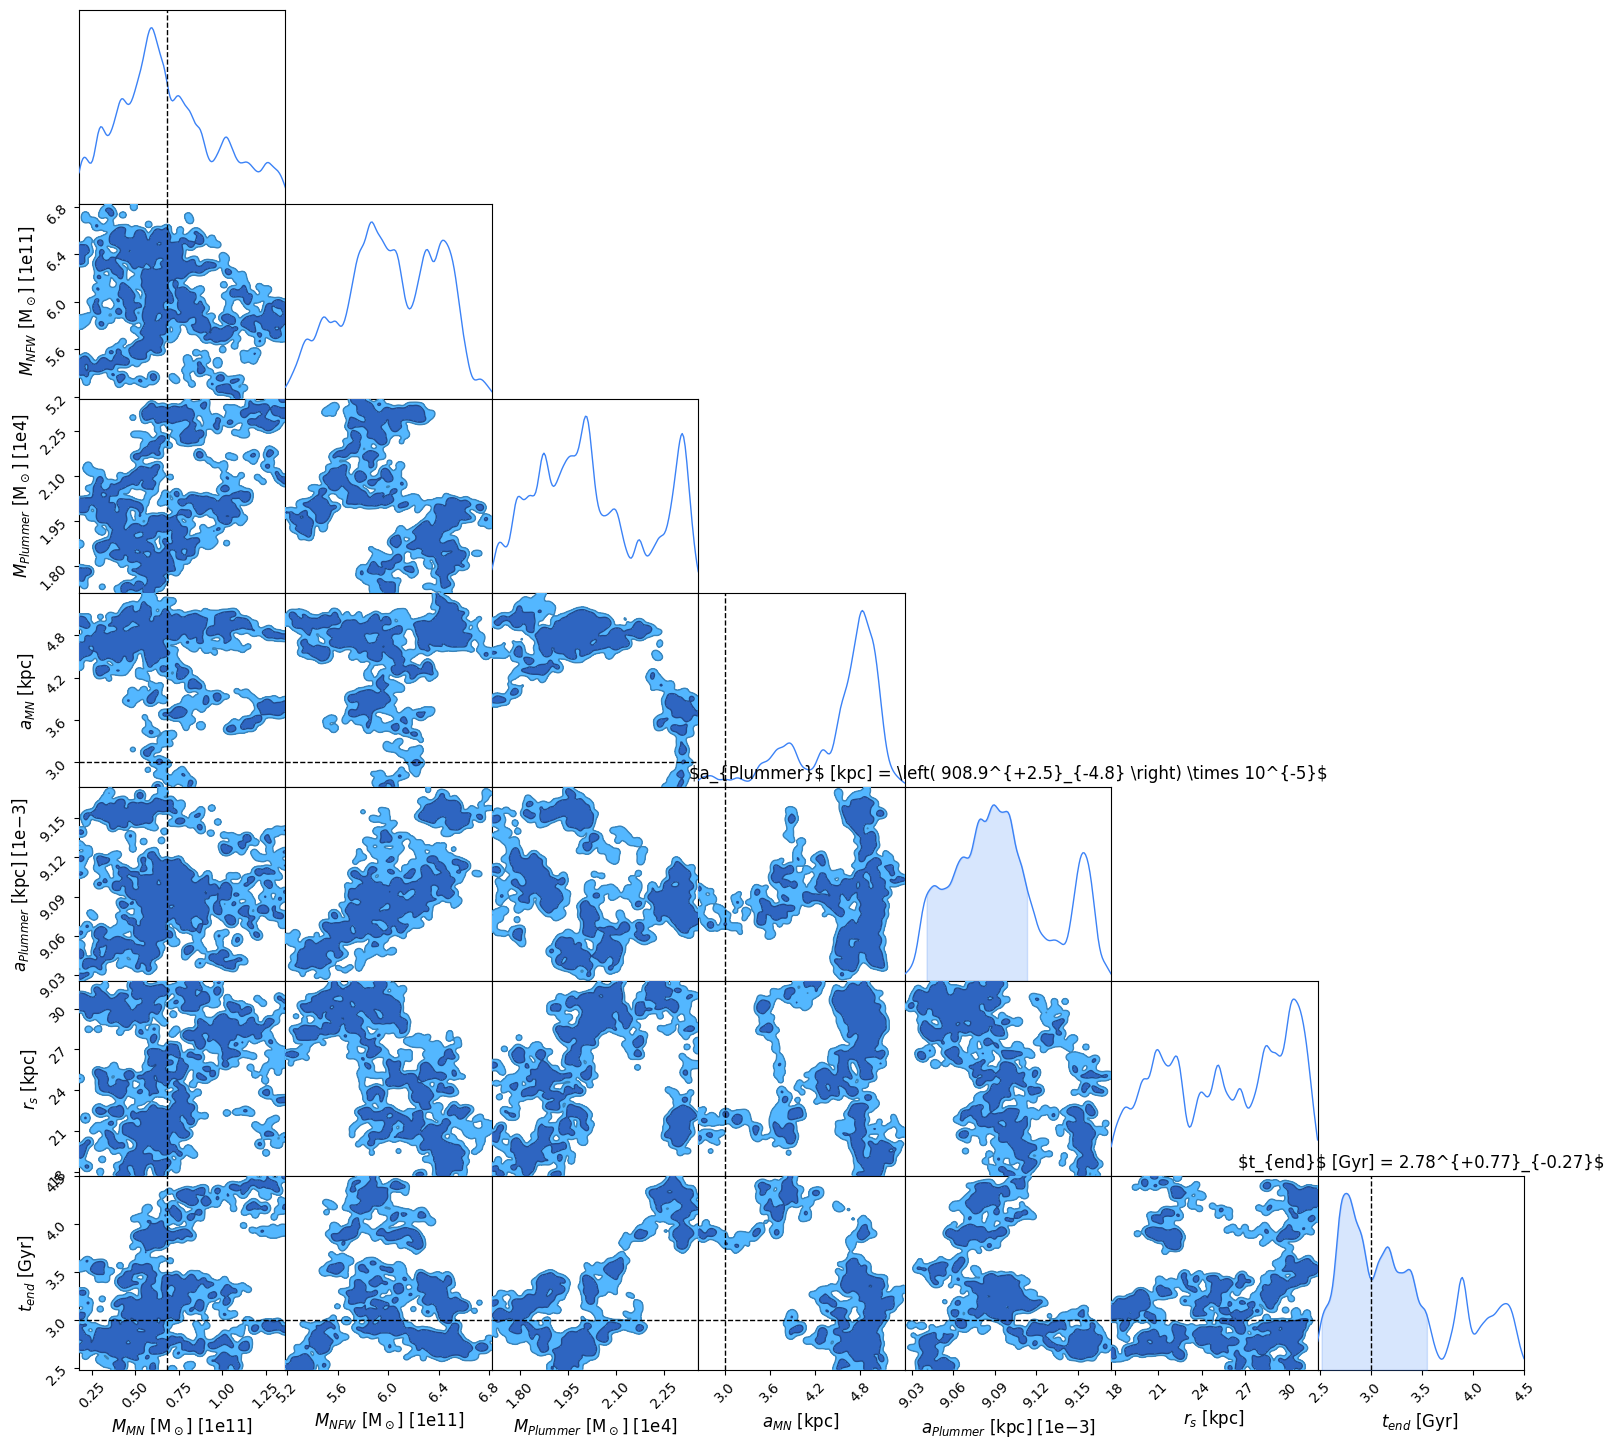


📊 MCMC Summary (filtered accepted samples):
Number of samples: 867
Number of chains: 1

Parameter estimates (mean ± std):
------------------------------------------------------------
$M_{MN}$ [M$_\odot$]: 6.859562e+10 ± 2.822726e+10
True value          : 6.819390e+10
Bias (σ)            : 0.01
------------------------------------------------------------
$M_{NFW}$ [M$_\odot$]: 6.022827e+11 ± 3.663354e+10
True value          : 4.368332e+11
Bias (σ)            : 4.52
------------------------------------------------------------
$M_{Plummer}$ [M$_\odot$]: 2.025412e+04 ± 1.761207e+03
True value          : 1.122018e+04
Bias (σ)            : 5.13
------------------------------------------------------------
$a_{MN}$ [kpc]      : 4.508254e+00 ± 5.770351e-01
True value          : 3.000000e+00
Bias (σ)            : 2.61
------------------------------------------------------------
$a_{Plummer}$ [kpc] : 9.095294e-03 ± 3.568161e-05
True value          : 8.000000e-03
Bias (σ)            : 30.70
-----

In [11]:
def convert_to_dataframe_filtered(positions_dict, is_accepted_mask):
    """Convert dictionary of arrays to DataFrame, filtering by acceptance. Works for single or multiple chains."""
    
    # Handle both single chain and multi-chain cases
    if len(positions_dict['t_end'].shape) == 1:
        # Single chain case: reshape to [1, num_samples]
        num_chains = 1
        num_samples = positions_dict['t_end'].shape[0]
        
        # Reshape all arrays to add chain dimension
        positions_reshaped = {}
        for param_name, values in positions_dict.items():
            positions_reshaped[param_name] = values.reshape(1, -1)
        
        # Reshape acceptance mask
        is_accepted_reshaped = is_accepted_mask.reshape(1, -1)
        
    else:
        # Multi-chain case: use as-is
        num_chains = positions_dict['t_end'].shape[0]
        num_samples = positions_dict['t_end'].shape[1]
        positions_reshaped = positions_dict
        is_accepted_reshaped = is_accepted_mask
    
    print(f"Original samples: {num_chains} chains × {num_samples} samples = {num_chains * num_samples}")
    
    all_samples = []
    
    for chain_id in range(num_chains):
        # Get acceptance mask for this chain
        chain_accepted = is_accepted_reshaped[chain_id, :]  # Boolean mask for this chain
        
        # Extract samples for this chain
        chain_data = {}
        for param_name, values in positions_reshaped.items():
            # Only keep accepted samples
            chain_data[param_name] = values[chain_id, chain_accepted]
        
        # Count accepted samples for this chain
        n_accepted = jnp.sum(chain_accepted)
        print(f"  Chain {chain_id}: {n_accepted}/{num_samples} accepted ({n_accepted/num_samples*100:.1f}%)")
        
        # Create DataFrame for this chain (only accepted samples)
        if n_accepted > 0:  # Only add if there are accepted samples
            df_chain = pd.DataFrame(chain_data)
            df_chain['chain_id'] = chain_id
            df_chain['original_sample_id'] = jnp.where(chain_accepted)[0]  # Track original indices
            
            all_samples.append(df_chain)
    
    if not all_samples:
        print("⚠️ Warning: No accepted samples found!")
        return pd.DataFrame()
    
    # Combine all chains
    combined_df = pd.concat(all_samples, ignore_index=True)
    total_accepted = len(combined_df)
    total_original = num_chains * num_samples
    
    print(f"📊 Total accepted samples: {total_accepted}/{total_original} ({total_accepted/total_original*100:.1f}%)")
    
    return combined_df

# Usage remains the same - works for both single and multiple chains
positions = history_state[0].position
is_accepted = history_state[1].is_accepted

# Convert with filtering (now works for single chain too)
df_all_filtered = convert_to_dataframe_filtered(positions, is_accepted)

# Rest of the code remains exactly the same
burn_in = 100  
thin_factor = 1  

if len(df_all_filtered) > 0:
    df_processed = df_all_filtered[
        (df_all_filtered['original_sample_id'] >= burn_in) & 
        (df_all_filtered['original_sample_id'] % thin_factor == 0)
    ].copy()
    
    # Remove metadata columns for plotting
    df_plot = df_processed.drop(['chain_id', 'original_sample_id'], axis=1)
    
    # Rename columns for nice LaTeX formatting
    df_plot.columns = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print(f"📈 Final samples for plotting: {len(df_plot)}")
    
    # Create ChainConsumer plot with true values
    from chainconsumer import Chain, ChainConsumer, Truth
    
    # Create Chain object
    chain = Chain(samples=df_plot, name="MCMC Posterior (Filtered)")
    
    # Create ChainConsumer object
    c = ChainConsumer()
    c.add_chain(chain)
    
    # Add true values
    true_values_dict = {
        '$M_{MN}$ [M$_\odot$]': 68_193_902_782.346756,
        '$M_{NFW}$ [M$_\odot$]': 4.3683325e11,
        '$M_{Plummer}$ [M$_\odot$]': 10**4.05,
        '$a_{MN}$ [kpc]': 3.0,
        '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
        '$r_s$ [kpc]': 16.0,
        '$t_{end}$ [Gyr]': 3.0,
    }
    
    truth = Truth(location=true_values_dict, name="True Parameters")
    c.add_truth(truth)
    
    # Create corner plot
    print("🎨 Creating corner plot...")
    fig = c.plotter.plot()
    plt.show()
    
    # Print summary statistics
    print("\n📊 MCMC Summary (filtered accepted samples):")
    print(f"Number of samples: {len(df_plot)}")
    print(f"Number of chains: {df_processed['chain_id'].nunique()}")
    
    # Calculate parameter statistics
    param_names = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print("\nParameter estimates (mean ± std):")
    print("-" * 60)
    for i, param in enumerate(param_names):
        col_name = df_plot.columns[i]
        mean_val = df_plot[col_name].mean()
        std_val = df_plot[col_name].std()
        true_val = list(true_values_dict.values())[i]
        
        print(f"{param:20s}: {mean_val:.6e} ± {std_val:.6e}")
        print(f"{'True value':20s}: {true_val:.6e}")
        print(f"{'Bias (σ)':20s}: {(mean_val - true_val) / std_val:.2f}")
        print("-" * 60)
    
else:
    print("❌ No samples available for plotting after filtering!")

In [12]:
init_positions

{'M_MN': Array(8.028854e+10, dtype=float32),
 'M_NFW': Array(5.3141445e+11, dtype=float32),
 'Mtot': Array(17032.932, dtype=float32),
 'a_MN': Array(3.6173007, dtype=float32),
 'a_Plummer': Array(0.00916946, dtype=float32),
 'r_s': Array(20.5701, dtype=float32),
 't_end': Array(2.84078, dtype=float32)}

# RMH Vectorized

In [3]:
from blackjax.util import run_inference_algorithm

# Fix: Create a proper random step function instead of passing an array
def random_step_fn(rng_key, position):
    """Generate random step proposals for each parameter."""
    # Use different step sizes for different parameters based on their scale
    # step_sizes = jnp.array([
    #     0.1,    # t_end (Gyr) - smaller steps
    #     100.0,  # Mtot (Msun) - larger steps for large values
    #     0.001,  # a_Plummer (kpc) - very small steps
    #     1e10,    # M_NFW (Msun) - large steps for large values  
    #     1.0,    # r_s (kpc)
    #     1e9,    # M_MN (Msun) - large steps for large values
    #     0.2,    # a_MN (kpc)
    # ])
    step_sizes = jnp.array([
        0.5*1,    # t_end (Gyr) - smaller steps
        0.5*3000.0,  # Mtot (Msun) - larger steps for large values
        0.5*0.0001,  # a_Plummer (kpc) - very small steps
        0.5*1e11,    # M_NFW (Msun) - large steps for large values  
        0.5*10.0,    # r_s (kpc)
        0.5*1e11,    # M_MN (Msun) - large steps for large values
        0.5*1,    # a_MN (kpc)
    ])
    
    # Generate random steps
    random_steps = jax.random.normal(rng_key, shape=(7,)) * 0.1 * step_sizes
    
    # Convert to dictionary format to match your position format
    step_dict = {
        't_end': random_steps[0],
        'Mtot': random_steps[1], 
        'a_Plummer': random_steps[2],
        'M_NFW': random_steps[3],
        'r_s': random_steps[4],
        'M_MN': random_steps[5],
        'a_MN': random_steps[6]
    }
    return step_dict

@partial(jit, static_argnames=['num_chains'])
def run_inference_vmap(rng_key, num_chains=5):
    rng_keys = jax.random.split(rng_key, num_chains)
    intial_positions = jax.vmap(draw_from_prior)(rng_keys)
    # print(intial_positions)
    

    def extract_single_position(idx):
        """Extract a single position dict from the vmapped result."""
        return {key: values[idx] for key, values in intial_positions.items()}
    
    run_inference_vmap = lambda i: run_inference_algorithm(
        rng_key=rng_keys[i],
        inference_algorithm=blackjax.additive_step_random_walk(
                                    logdensity_fn=evaluate_log_posterior,
                                    random_step=random_step_fn
                                ),
        num_steps=1000,
        initial_position=extract_single_position(i),
        progress_bar=False,
    )

    return jax.vmap(run_inference_vmap)(jnp.arange(num_chains))
  
print('start running chains')
# history = run_inference_vmap(jax.random.PRNGKey(42), num_chains=2)

start running chains


In [ ]:
def create_initial_positions_near_sbi(rng_key, num_chains, sbi_posterior_path, dispersion_factor=0.1):
    """
    Create initial positions for MCMC chains near the SBI posterior mean.
    
    Parameters
    ----------
    rng_key : jax.random.PRNGKey
        Random key for generating dispersed positions
    num_chains : int
        Number of chains to initialize
    sbi_posterior_path : str
        Path to the SBI posterior samples
    dispersion_factor : float
        Factor to control how spread out the initial positions are
        (fraction of posterior std for each parameter)
    
    Returns
    -------
    dict
        Dictionary with arrays of shape (num_chains,) for each parameter
    """
    
    # Load SBI posterior samples
    posterior_SBI = np.load(sbi_posterior_path)['predicted_theta'][0]
    
    # Calculate mean and std for each parameter
    posterior_mean = np.mean(posterior_SBI, axis=0)
    posterior_std = np.std(posterior_SBI, axis=0)
    
    # Convert mean to dictionary format and apply transformations
    mean_dict = array_to_dict(posterior_mean)
    mean_dict['M_NFW'] = 10**mean_dict['M_NFW']
    mean_dict['M_MN'] = 10**mean_dict['M_MN']
    mean_dict['Mtot'] = 10**mean_dict['Mtot']
    
    # Create std dictionary with transformations
    # For log-transformed parameters, we need to be careful with the std
    std_dict = array_to_dict(posterior_std)
    
    # For log-transformed parameters, convert std appropriately
    # If x ~ N(μ, σ²), then 10^x has different dispersion
    std_dict['M_NFW'] = mean_dict['M_NFW'] * std_dict['M_NFW'] * np.log(10)  # Chain rule for log transform
    std_dict['M_MN'] = mean_dict['M_MN'] * std_dict['M_MN'] * np.log(10)
    std_dict['Mtot'] = mean_dict['Mtot'] * std_dict['Mtot'] * np.log(10)
    
    # Generate dispersed initial positions
    rng_keys = jax.random.split(rng_key, num_chains)
    
    def generate_single_position(key):
        """Generate a single initial position near the SBI mean."""
        position = {}
        for param_name in param_order:
            # Add Gaussian noise around the mean
            noise = jax.random.normal(key, shape=()) * std_dict[param_name] * dispersion_factor
            position[param_name] = mean_dict[param_name] + noise
            
            # Ensure parameters stay within prior bounds
            param_idx = param_order.index(param_name)
            position[param_name] = jnp.clip(
                position[param_name], 
                prior_bounds[param_idx, 0], 
                prior_bounds[param_idx, 1]
            )
        return position
    
    # Generate all positions
    positions_list = [generate_single_position(key) for key in rng_keys]
    
    # Convert to dictionary of arrays format (like draw_from_prior returns)
    initial_positions = {}
    for param_name in param_order:
        initial_positions[param_name] = jnp.array([pos[param_name] for pos in positions_list])
    
    return initial_positions

# Modified run_inference_vmap function
@partial(jit, static_argnames=['num_chains', 'use_sbi_init'])
def run_inference_vmap(rng_key, num_chains=5, use_sbi_init=True, sbi_path='../logs/OdisseoCrossAttentionSetTransformer_small_AllParameters_Position_uniforprior_2e5_TSIT5/pictures/predicted_theta_test_set.npz'):
    rng_keys = jax.random.split(rng_key, num_chains)
    
    if use_sbi_init and sbi_path is not None:
        # Use SBI posterior mean as starting point
        initial_positions = create_initial_positions_near_sbi(
            rng_key, 
            num_chains, 
            sbi_path,
            dispersion_factor=0.05  # Small dispersion around SBI mean
        )
    else:
        # Use prior sampling as before
        initial_positions = jax.vmap(draw_from_prior)(rng_keys)
    
    def extract_single_position(idx):
        """Extract a single position dict from the vmapped result."""
        return {key: values[idx] for key, values in initial_positions.items()}
    
    run_inference_single = lambda i: run_inference_algorithm(
        rng_key=rng_keys[i],
        inference_algorithm=blackjax.additive_step_random_walk(
            logdensity_fn=evaluate_log_posterior,
            random_step=random_step_fn
        ),
        num_steps=10_000,
        initial_position=extract_single_position(i),
        progress_bar=False,
    )

    return jax.vmap(run_inference_single)(jnp.arange(num_chains))

print('start running chains')
history = run_inference_vmap(jax.random.PRNGKey(42), num_chains=15, use_sbi_init=True)

start running chains


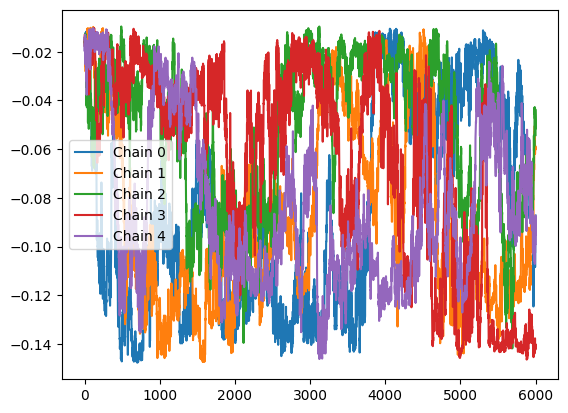

In [ ]:
for i in range(history[1][0].logdensity.shape[0]):
    plt.plot(history[1][0].logdensity[i], label=f'Chain {i}')
    plt.legend()

In [ ]:
history[1][1].is_accepted

Array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]], dtype=bool)

Original samples: 5 chains × 6000 samples = 30000
  Chain 0: 5546/6000 accepted (92.4%)
  Chain 1: 5612/6000 accepted (93.5%)
  Chain 2: 5610/6000 accepted (93.5%)
  Chain 3: 5572/6000 accepted (92.9%)
  Chain 4: 5611/6000 accepted (93.5%)
📊 Total accepted samples: 27951/30000 (93.2%)
📈 Final samples for plotting: 1639
🎨 Creating corner plot...


Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{MN}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{Plummer}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $r_s$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $t_{end}$ [Gyr] in chain MCMC Posterior (Filtered) is not constrained


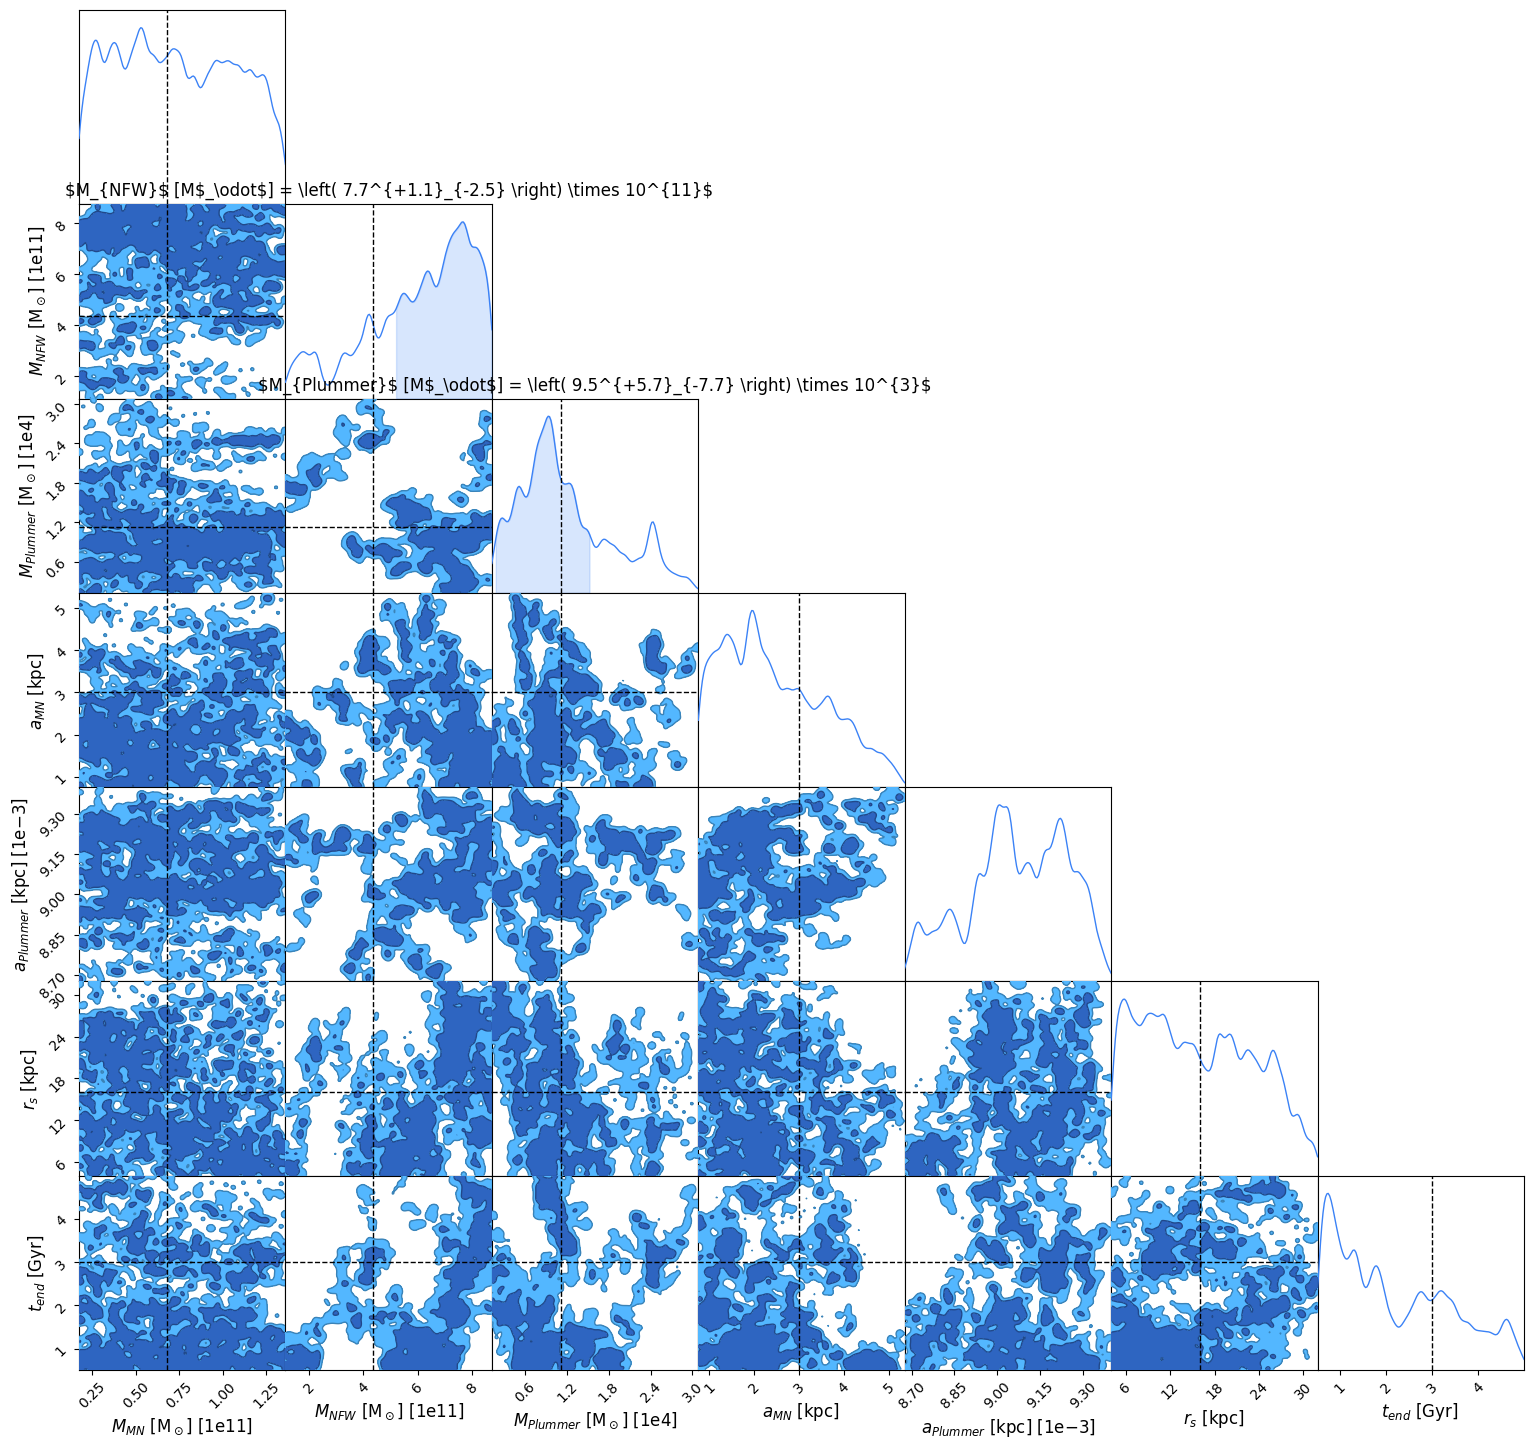


📊 MCMC Summary (filtered accepted samples):
Number of samples: 1639
Number of chains: 5

Parameter estimates (mean ± std):
------------------------------------------------------------
$M_{MN}$ [M$_\odot$]: 7.354201e+10 ± 3.315677e+10
True value          : 3.000000e+00
Bias (σ)            : 2.22
------------------------------------------------------------
$M_{NFW}$ [M$_\odot$]: 6.042831e+11 ± 1.953552e+11
True value          : 1.122018e+04
Bias (σ)            : 3.09
------------------------------------------------------------
$M_{Plummer}$ [M$_\odot$]: 1.211926e+04 ± 6.906360e+03
True value          : 8.000000e-03
Bias (σ)            : 1.75
------------------------------------------------------------
$a_{MN}$ [kpc]      : 2.462690e+00 ± 1.131164e+00
True value          : 4.368332e+11
Bias (σ)            : -386180284416.00
------------------------------------------------------------
$a_{Plummer}$ [kpc] : 9.069181e-03 ± 1.711581e-04
True value          : 1.600000e+01
Bias (σ)            

In [ ]:
def convert_multichain_to_dataframe_filtered(positions_dict, is_accepted_mask):
    """Convert dictionary of [num_chains, num_samples] arrays to DataFrame, filtering by acceptance."""
    
    all_samples = []
    num_chains = positions_dict['t_end'].shape[0]
    num_samples = positions_dict['t_end'].shape[1]
    
    print(f"Original samples: {num_chains} chains × {num_samples} samples = {num_chains * num_samples}")
    
    for chain_id in range(num_chains):
        # Get acceptance mask for this chain
        chain_accepted = is_accepted_mask[chain_id, :]  # Boolean mask for this chain
        
        # Extract samples for this chain
        chain_data = {}
        for param_name, values in positions_dict.items():
            # Only keep accepted samples
            chain_data[param_name] = values[chain_id, chain_accepted]
        
        # Count accepted samples for this chain
        n_accepted = jnp.sum(chain_accepted)
        print(f"  Chain {chain_id}: {n_accepted}/{num_samples} accepted ({n_accepted/num_samples*100:.1f}%)")
        
        # Create DataFrame for this chain (only accepted samples)
        if n_accepted > 0:  # Only add if there are accepted samples
            df_chain = pd.DataFrame(chain_data)
            df_chain['chain_id'] = chain_id
            df_chain['original_sample_id'] = jnp.where(chain_accepted)[0]  # Track original indices
            
            all_samples.append(df_chain)
    
    if not all_samples:
        print("⚠️ Warning: No accepted samples found!")
        return pd.DataFrame()
    
    # Combine all chains
    combined_df = pd.concat(all_samples, ignore_index=True)
    total_accepted = len(combined_df)
    total_original = num_chains * num_samples
    
    print(f"📊 Total accepted samples: {total_accepted}/{total_original} ({total_accepted/total_original*100:.1f}%)")
    
    return combined_df

# Use the filtered conversion
positions = history[1][0].position
is_accepted = history[1][1].is_accepted

# Convert with filtering
df_all_filtered = convert_multichain_to_dataframe_filtered(positions, is_accepted)

# Apply additional burn-in and thinning if needed
burn_in = 2500  # Fewer since we already filtered by acceptance
thin_factor = 10  # Less thinning since we have fewer samples

if len(df_all_filtered) > 0:
    df_processed = df_all_filtered[
        (df_all_filtered['original_sample_id'] >= burn_in) & 
        (df_all_filtered['original_sample_id'] % thin_factor == 0)
    ].copy()
    
    # Remove metadata columns for plotting
    df_plot = df_processed.drop(['chain_id', 'original_sample_id'], axis=1)
    
    # Rename columns for nice LaTeX formatting
    df_plot.columns = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print(f"📈 Final samples for plotting: {len(df_plot)}")
    
    # Create ChainConsumer plot with true values
    from chainconsumer import Chain, ChainConsumer, Truth
    
    # Create Chain object
    chain = Chain(samples=df_plot, name="MCMC Posterior (Filtered)")
    
    # Create ChainConsumer object
    c = ChainConsumer()
    c.add_chain(chain)
    
    # Add true values
    true_values_dict = {
        '$t_{end}$ [Gyr]': 3.0,
        '$M_{Plummer}$ [M$_\odot$]': 10**4.05,
        '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
        '$M_{NFW}$ [M$_\odot$]': 4.3683325e11,
        '$r_s$ [kpc]': 16.0,
        '$M_{MN}$ [M$_\odot$]': 68_193_902_782.346756,
        '$a_{MN}$ [kpc]': 3.0
    }
    
    truth = Truth(location=true_values_dict, name="True Parameters")
    c.add_truth(truth)
    
    # Create corner plot
    print("🎨 Creating corner plot...")
    fig = c.plotter.plot()
    plt.show()
    
    # Print summary statistics
    print("\n📊 MCMC Summary (filtered accepted samples):")
    print(f"Number of samples: {len(df_plot)}")
    print(f"Number of chains: {df_processed['chain_id'].nunique()}")
    
    # Calculate parameter statistics
    param_names = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print("\nParameter estimates (mean ± std):")
    print("-" * 60)
    for i, param in enumerate(param_names):
        col_name = df_plot.columns[i]
        mean_val = df_plot[col_name].mean()
        std_val = df_plot[col_name].std()
        true_val = list(true_values_dict.values())[i]
        
        print(f"{param:20s}: {mean_val:.6e} ± {std_val:.6e}")
        print(f"{'True value':20s}: {true_val:.6e}")
        print(f"{'Bias (σ)':20s}: {(mean_val - true_val) / std_val:.2f}")
        print("-" * 60)
    
else:
    print("❌ No samples available for plotting after filtering!")

# Plotting from file

In [3]:
df_all_filtered = pd.read_csv('./mcmc_samples_filtered.csv')
df_all_filtered.head()

,M_MN,M_NFW,Mtot,a_MN,a_Plummer,r_s,t_end,chain_id,original_sample_id
0,5.395979e+10,2.062110e+11,3709.7593,4.447958,0.006794,30.481577,2.396865,0,1
1,5.460409e+10,2.077233e+11,3853.6567,4.386364,0.005564,29.913061,2.388930,0,2
2,5.339037e+10,2.138972e+11,3890.9148,4.312272,0.003677,28.205208,2.272749,0,3
3,5.389996e+10,2.202399e+11,3829.5234,4.341014,0.003422,28.936502,2.401712,0,4
4,5.394881e+10,2.223104e+11,3828.4734,4.201054,0.003790,28.779718,2.308783,0,5


📈 Final samples for plotting: 3079
🎨 Creating corner plot...


Parameter $M_{MN}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{NFW}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $M_{Plummer}$ [M$_\odot$] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{MN}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $a_{Plummer}$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $r_s$ [kpc] in chain MCMC Posterior (Filtered) is not constrained
Parameter $t_{end}$ [Gyr] in chain MCMC Posterior (Filtered) is not constrained


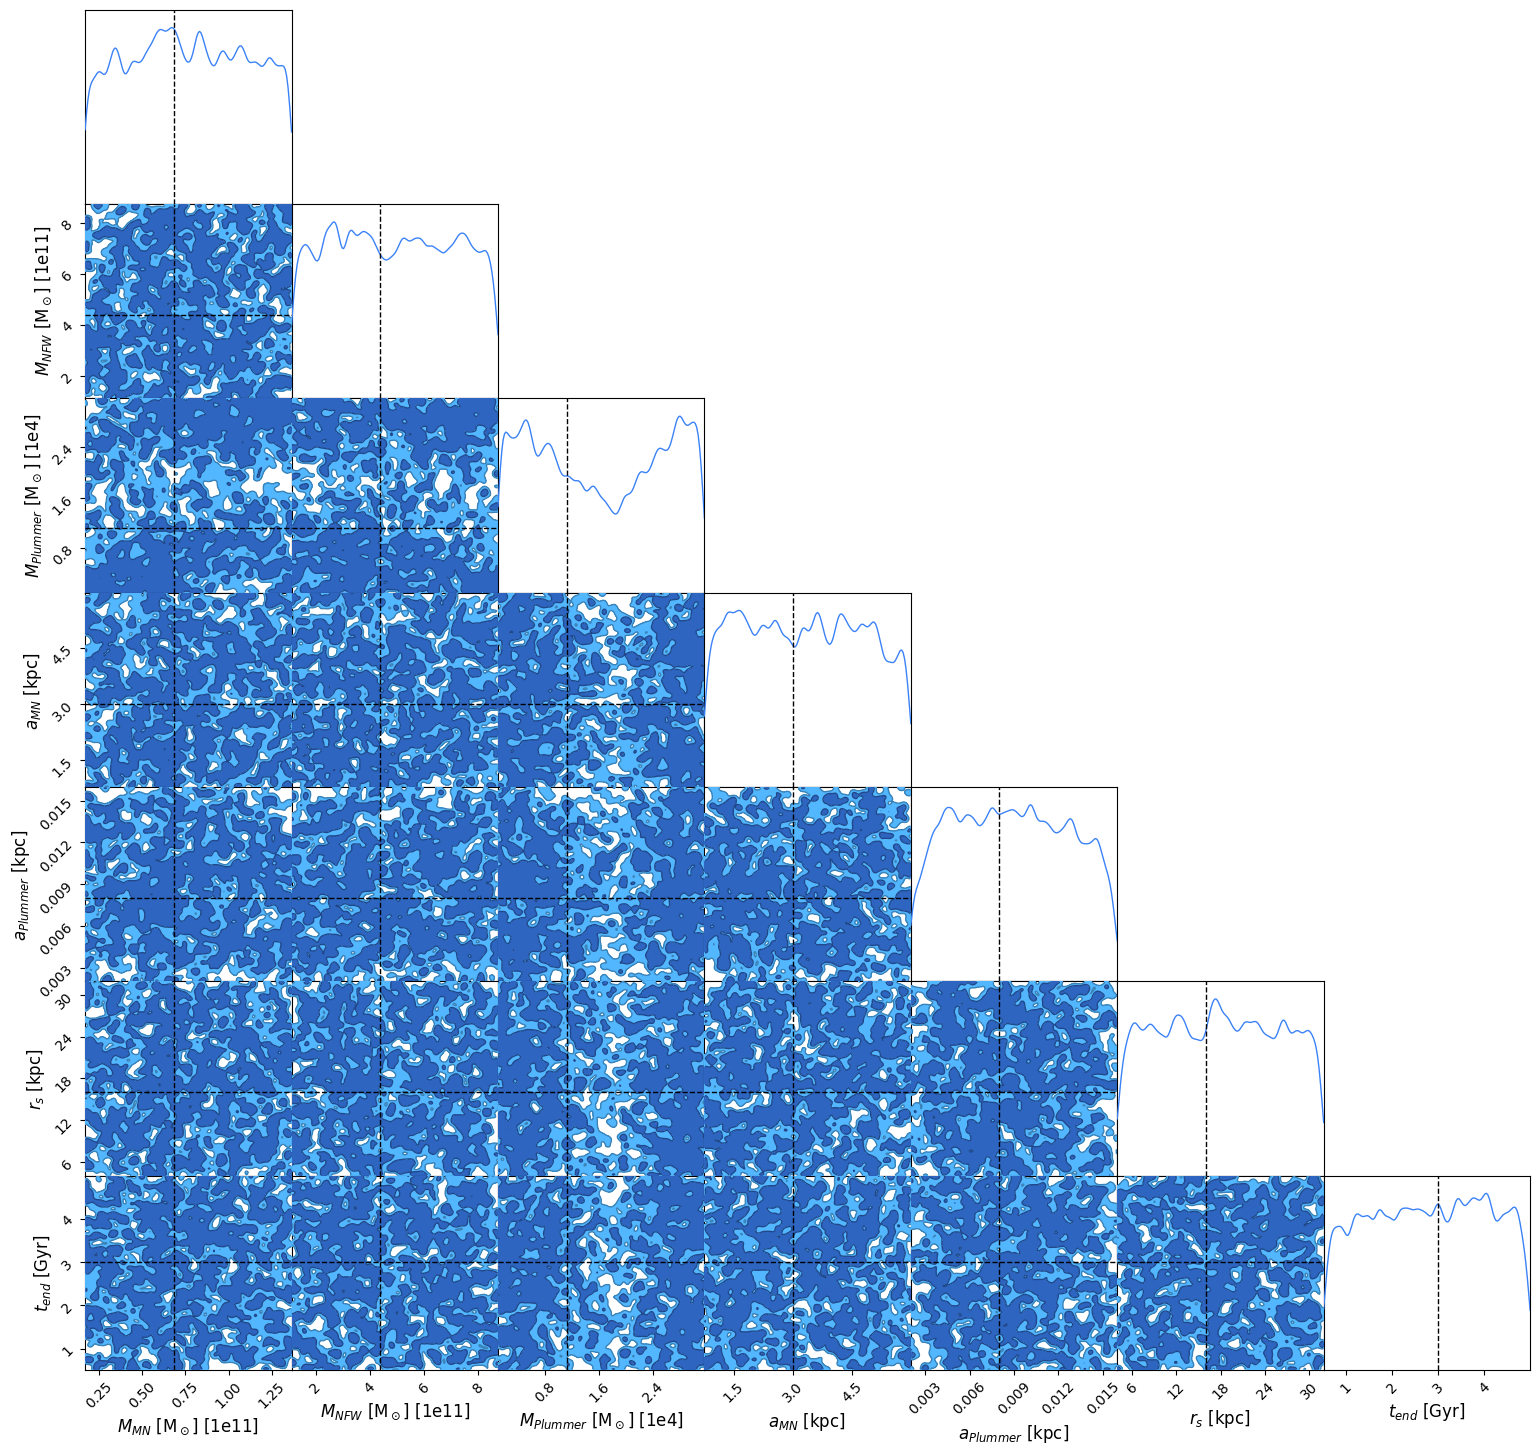


📊 MCMC Summary (filtered accepted samples):
Number of samples: 3079
Number of chains: 20

Parameter estimates (mean ± std):
------------------------------------------------------------
$M_{MN}$ [M$_\odot$]: 7.683858e+10 ± 3.360317e+10
True value          : 6.819390e+10
Bias (σ)            : 0.26
------------------------------------------------------------
$M_{NFW}$ [M$_\odot$]: 4.889703e+11 ± 2.174945e+11
True value          : 4.368332e+11
Bias (σ)            : 0.24
------------------------------------------------------------
$M_{Plummer}$ [M$_\odot$]: 1.625005e+04 ± 9.564209e+03
True value          : 1.122018e+04
Bias (σ)            : 0.53
------------------------------------------------------------
$a_{MN}$ [kpc]      : 3.312119e+00 ± 1.485367e+00
True value          : 3.000000e+00
Bias (σ)            : 0.21
------------------------------------------------------------
$a_{Plummer}$ [kpc] : 8.874842e-03 ± 3.784329e-03
True value          : 8.000000e-03
Bias (σ)            : 0.23
----

In [ ]:
# Apply additional burn-in and thinning if needed
burn_in = 1_000  # Fewer since we already filtered by acceptance
thin_factor = 2  # Less thinning since we have fewer samples

if len(df_all_filtered) > 0:
    df_processed = df_all_filtered[
        (df_all_filtered['original_sample_id'] >= burn_in) & 
        (df_all_filtered['original_sample_id'] % thin_factor == 0)
    ].copy()
    
    # Remove metadata columns for plotting
    df_plot = df_processed.drop(['chain_id', 'original_sample_id'], axis=1)
    
    # Rename columns for nice LaTeX formatting
    df_plot.columns = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print(f"📈 Final samples for plotting: {len(df_plot)}")
    
    # Create ChainConsumer plot with true values
    from chainconsumer import Chain, ChainConsumer, Truth
    
    # Create Chain object
    chain = Chain(samples=df_plot, name="MCMC Posterior (Filtered)")
    
    # Create ChainConsumer object
    c = ChainConsumer()
    c.add_chain(chain)
    
    # Add true values
    true_values_dict = {
        '$M_{MN}$ [M$_\odot$]': 68_193_902_782.346756,
        '$M_{NFW}$ [M$_\odot$]': 4.3683325e11,
        '$M_{Plummer}$ [M$_\odot$]': 10**4.05,
        '$a_{MN}$ [kpc]': 3.0,
        '$a_{Plummer}$ [kpc]': 8.0 * 1e-3,
        '$r_s$ [kpc]': 16.0,
        '$t_{end}$ [Gyr]': 3.0,
    }
    
    truth = Truth(location=true_values_dict, name="True Parameters")
    c.add_truth(truth)
    
    # Create corner plot
    print("🎨 Creating corner plot...")
    fig = c.plotter.plot()
    plt.show()
    
    # Print summary statistics
    print("\n📊 MCMC Summary (filtered accepted samples):")
    print(f"Number of samples: {len(df_plot)}")
    print(f"Number of chains: {df_processed['chain_id'].nunique()}")
    
    # Calculate parameter statistics
    param_names = ['$M_{MN}$ [M$_\odot$]', '$M_{NFW}$ [M$_\odot$]', '$M_{Plummer}$ [M$_\odot$]', '$a_{MN}$ [kpc]', '$a_{Plummer}$ [kpc]', '$r_s$ [kpc]', '$t_{end}$ [Gyr]']
    
    print("\nParameter estimates (mean ± std):")
    print("-" * 60)
    for i, param in enumerate(param_names):
        col_name = df_plot.columns[i]
        mean_val = df_plot[col_name].mean()
        std_val = df_plot[col_name].std()
        true_val = list(true_values_dict.values())[i]
        
        print(f"{param:20s}: {mean_val:.6e} ± {std_val:.6e}")
        print(f"{'True value':20s}: {true_val:.6e}")
        print(f"{'Bias (σ)':20s}: {(mean_val - true_val) / std_val:.2f}")
        print("-" * 60)
    
else:
    print("❌ No samples available for plotting after filtering!")

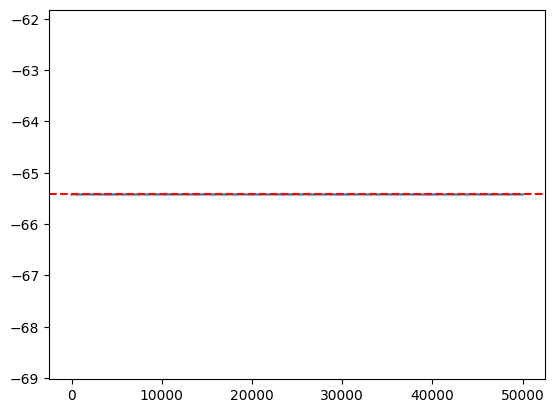

In [6]:
chains_logdensity = np.load('./mcmc_logdensity.npy')
plt.plot(chains_logdensity[4], label='Chain 0')
plt.axhline(np.mean(chains_logdensity[4]), color='red', linestyle='--', label='Max Log-Likelihood')
# plt.xscale('log')